# Distributed Coffea Jobs at UW Analysis Facility

This notebook demonstrates how one can run a full coffea (version >= 2025.5) analysis with Condor jobs on the Analysis Facility's cluster. As with the other notebooks, you should have already run your `voms-proxy-init` command in a terminal window before running anything here, as this example does access files remotely with XRootD.

This notebook can also be used as a template for many coffea analyses. It does not exhaustively demonstrate the capabilities of the Analysis Facility or of the coffea software ecosystem, but this template should at least get an analysis up and running with some tweaks.

In [24]:
import awkward as ak
from coffea.analysis_tools import PackedSelection
import coffea.processor as processor
import cowtools.jobqueue
from hist import Hist, axis
import matplotlib.pyplot as plt
import mplhep as hep

We'll configure some settings here to be used later.

`MAX_WORKERS`: The maximum number of Condor workers to try and use at a time.<br>
`CHUNKSIZE`: The number of events in one chunk. Unless you have a reason to use something else, 10,000 and 5,000 are decent starting points.<br>
`MAX_CHUNKS`: The maximum number of chunks to run over. For example, if you want to run on only 20,000 events and your chunk size is 5,000, you could set MAX_CHUNKS to 4.

In [2]:
MAX_WORKERS = 5
CHUNKSIZE = 5000
MAX_CHUNKS = None

Next, we define our fileset. The fileset should be a dictionary mapping dataset names to lists of files. We are using XRootD for file access here, so we give the file addresses with the FNAL redirector. You can also put local files here.

In [3]:
redirector = "root://cmsxrootd.fnal.gov//"

ll_fileset = {
    "ggZH_HToBB_ZToLL": [
        redirector+"/store/mc/RunIISummer20UL18NanoAODv9/ggZH_HToBB_ZToLL_M-125_TuneCP5_13TeV-powheg-pythia8/NANOAODSIM/106X_upgrade2018_realistic_v16_L1v1-v1/2520000/1412A75E-6CBA-5142-914D-2FE8356F680C.root",
        redirector+"/store/mc/RunIISummer20UL18NanoAODv9/ggZH_HToBB_ZToLL_M-125_TuneCP5_13TeV-powheg-pythia8/NANOAODSIM/106X_upgrade2018_realistic_v16_L1v1-v1/2520000/7D3C5290-C72C-B140-9233-D7DA01D4B183.root"
    ],
    "ZH_HToBB_ZToLL": [
        redirector+"/store/mc/RunIISummer20UL18NanoAODv9/ZH_HToBB_ZToLL_M-125_TuneCP5_13TeV-powheg-pythia8/NANOAODSIM/106X_upgrade2018_realistic_v16_L1v1-v1/2520000/56097D21-719D-564E-8E4A-C65214F252F9.root",
        redirector+"/store/mc/RunIISummer20UL18NanoAODv9/ZH_HToBB_ZToLL_M-125_TuneCP5_13TeV-powheg-pythia8/NANOAODSIM/106X_upgrade2018_realistic_v16_L1v1-v1/2820000/FE6AF237-7A43-C640-A0C0-672C18B80526.root"
    ]
}

Now, we write the coffea processor. This contains the logic and "physics" of our analysis. To make sure the class has the right structure, we inherit from the class `coffea.processor.ProcessorABC`. Our analysis goes primarily under the `process` method, which is mandatory. It should return an accumulatable object, as in the previous example notebook on accumulators and Hist.

For more examples of how processors (and other coffea analyses) can look, see [this Github discussion](https://github.com/CoffeaTeam/coffea/discussions/829).

In [4]:
class ExampleProcessor(processor.ProcessorABC):

    def __init__(self):
        '''
        An example function that counts the events in files, adds one for each chunk processed, and fills a histogram with arbitrarily chosen data.
        '''
        pass

    def process(self,events):
        dataset = events.metadata["dataset"]

        myAxis = axis.Regular(10,-0.5,9.5,name='data',label='example data')
    
        output = {
            "EventCount": 0,
            "Test": 0,
            "OtherTest": 0,
            "MyHist": Hist(myAxis) #Create a dask.hist.Hist instead of regular Hist, since our function will run in delayed mode
        }
    
        #Do some physics here (make cuts, select objects, calculate masses, etc.)
        
        #Fill in output
        output["Test"] += ak.sum(ak.ones_like(events.Electron.pt))
        output["OtherTest"] += ak.prod(ak.where(events.Electron.charge < 0, 5, -2))
        output["EventCount"] += ak.num(events,axis=0)
        output["MyHist"].fill(ak.num(events.Jet)) #Histogram the number of jets in each event

        return {dataset: output}

    def postprocess(self,accumulator):
        pass

## Running Locally

Now, we want to run this processor. We'll do it locally first, which is always good for testing, and then we'll run it on the cluster.

We start by making an executor object, which tells coffea how we want to run our processor. In this case, we create an `IterativeExecutor`, which runs locally. Then, we pass that executor, our processor, and our fileset to a `Runner`, which actually runs our analysis code. Note that when we create the runner, we assume the tree of interest in each ROOT file is called "Events". One can also run on non-ROOT files like parquet, or with different tree names. For this, see the coffea documentation and examples linked above.

In [5]:
#Create the executor, and have a status bar to show progress
local_executor = processor.IterativeExecutor(status=True)

#Create the runner
print("Creating runner")
print("Using chunksize: {} and maxchunks {}".format(CHUNKSIZE,MAX_CHUNKS))
runner = processor.Runner(
    executor=local_executor,
    chunksize=CHUNKSIZE,
    maxchunks=MAX_CHUNKS,
    skipbadfiles=True,
    xrootdtimeout=300,
)

Creating runner
Using chunksize: 5000 and maxchunks None


In [6]:
print("Calling runner")
ll_results_local = runner(
    ll_fileset,
    treename="Events",
    processor_instance=ExampleProcessor(),
)

Output()

Calling runner


Output()

/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:283: RuntimeWarning: Missing 
cross-reference index for LowPtElectron_electronIdx => Electron
  warnings.warn(

/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:283: RuntimeWarning: Missing 
cross-reference index for LowPtElectron_photonIdx => Photon
  warnings.warn(

/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:322: RuntimeWarning: Branch 
Photon_mass already exists but its values will be replaced with 0.0
  warnings.warn(

/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:322: RuntimeWarning: Branch 
Photon_charge already exists but its values will be replaced with 0.0
  warnings.warn(

Now that we ran our processor, we can examine the results, and then move on to running our jobs through Condor.

Dataset: ggZH_HToBB_ZToLL
Event count: 14000
Test value: 19245.0
Other test value: 0
Dataset: ZH_HToBB_ZToLL
Event count: 300312
Test value: 337925.0
Other test value: 0


[StairsArtists(stairs=<matplotlib.patches.StepPatch object at 0x7fc356447530>, errorbar=None, legend_artist=None)]

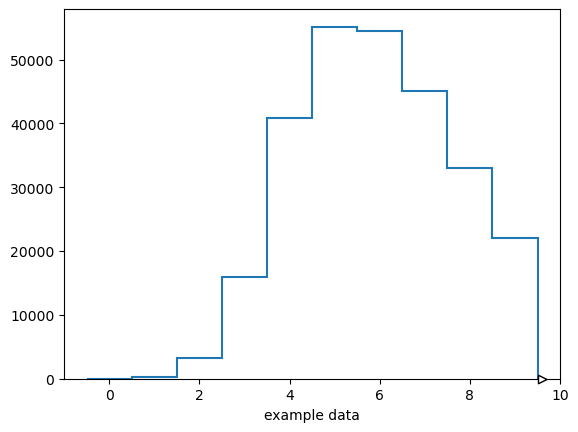

In [8]:
for dset,results in ll_results_local.items():
    print(f"Dataset: {dset}")
    print(f"Event count: {results['EventCount']}")
    print(f"Test value: {results['Test']}")
    print(f"Other test value: {results['OtherTest']}")

ll_results_local["ZH_HToBB_ZToLL"]["MyHist"].plot()

## Running on Condor

This next cell gets you ready to run on Condor, including taking any specifications the user needs to make for the Condor cluster.

We make use of `cowtools`, which is a package written specifically for the Wisconsin Analysis Facility. Among other functionalities, it connects the interactive node (where you are currently working) to a Condor cluster, where you can run jobs on many workers simultaneously. See [cowtools](https://github.com/rpsimeon34/cowtools).

In [9]:
client = cowtools.jobqueue.GetCondorClient(max_workers=MAX_WORKERS)
dask_executor = processor.DaskExecutor(client=client, status=True)
print("Executor created")

client

dask workers will run in /cvmfs/unpacked.cern.ch/registry.hub.docker.com/coffeateam/coffea-dask-almalinux9:2025.12.0-py3.12
Condor logs, output files, error files in /scratch/rsimeon
Executor created


/usr/local/lib/python3.12/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 16107 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: dask_jobqueue.HTCondorCluster
Dashboard: proxy/16107/status,
Dashboard: proxy/16107/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://144.92.181.248:4237,Workers: 0
Dashboard: proxy/16107/status,Total threads: 0
Started: Just now,Total memory: 0 B


The above cell should have produced a `Client` object, with a button that says "Launch dashboard in JupyterLab". Clicking that button will allow you to see the memory usage and worker status of your Condor workers in roughly real time. We also created an executor object, much like when we ran locally, except now it is a `DaskExecutor`, which knows about our Condor workers and gives them jobs.

The next cells create another runner with our Dask executor, and then runs the distributed jobs. You should be able to see your jobs moving in the dashboard, but it may take a few minutes. Running the jobs should finish in under 10 minutes.

In [10]:
print("Creating runner")
print("Using chunksize: {} and maxchunks {}".format(CHUNKSIZE,MAX_CHUNKS))
runner = processor.Runner(
    executor=dask_executor,
    chunksize=CHUNKSIZE,
    maxchunks=MAX_CHUNKS,
    skipbadfiles=True,
    xrootdtimeout=300,
)

Creating runner
Using chunksize: 5000 and maxchunks None


In [11]:
print("Calling runner")
ll_results_dask = runner(
    ll_fileset,
    treename="Events",
    processor_instance=ExampleProcessor(),
)

Calling runner


Output()

Again, we can look at the results.

Dataset: ZH_HToBB_ZToLL
Event count: 300312
Dataset: ggZH_HToBB_ZToLL
Event count: 14000


[StairsArtists(stairs=<matplotlib.patches.StepPatch object at 0x7fc356fcaa80>, errorbar=None, legend_artist=None)]

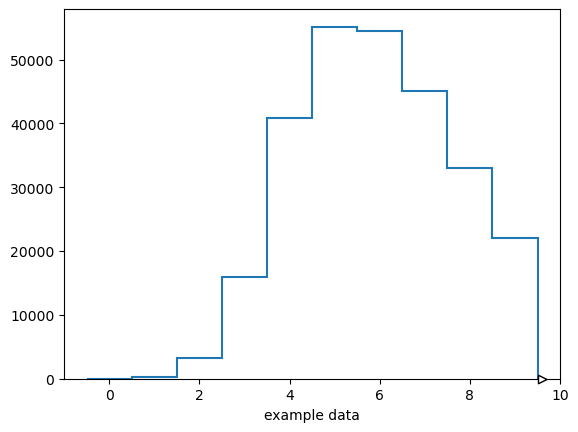

In [13]:
for dset,results in ll_results_dask.items():
    print(f"Dataset: {dset}")
    print(f"Event count: {results['EventCount']}")

ll_results_dask["ZH_HToBB_ZToLL"]["MyHist"].plot()

Finally, make sure to shut down your Condor client when you are done, just to avoid issues. If you forget, shutting down the notebook kernel also works.

In [14]:
client.shutdown()

## Examining Open Data

Finally, this section demonstrates a slightly more realistic bit of physics analysis code - calculating the dimuon mass in simulated
events. We'll make use of CMS Open Data to do this, so this section can actually be run without a VOMS proxy, if necessary.

In [15]:
redirector = "root://eospublic.cern.ch/" #Switch redirectors, now using one for Open Data

fileset_OpenData = {
    "ZToMuMu": [
        redirector+"/eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/ZToMuMu_M-50To120_TuneCP5_13TeV-powheg-pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v1/270000/12A9C3FE-53A6-6141-BD3F-46ABEECBB093.root",
        redirector+"/eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/ZToMuMu_M-50To120_TuneCP5_13TeV-powheg-pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v1/270000/4E47807B-CBA0-844E-A32A-3E3318D327A1.root"
    ]
}

Now, we define a function to process the data. Here, we want to require that the events:

- Pass some trigger (say, Mu17_Mu8)
- Have exactly two muons passing tight tracker isolation ID
- Have exactly two muons with opposite charge

Then, we want to sum the muons' 4-momenta together, and plot the mass of the resulting 4-momentum. This should give us a peak around the Z mass (~91 GeV).

In [16]:
class DimuonMass(processor.ProcessorABC):

    def __init__(self):
        '''
        An example function that calculates and histograms the dimuon mass, subject to some cuts.
        '''
        pass

    def process(self,events):
        dataset = events.metadata["dataset"]

        #Make axis for histogram
        mass_axis = axis.Regular(20,40,140,name="mass",label="Dimuon Mass [GeV]")
    
        #Store output histogram
        output = {
            "EventCount": 0,
            "Mass": Hist(mass_axis,name="Events")
        }
    
        #Count total number of events processed
        output["EventCount"] += ak.num(events,axis=0)
        
        #Apply the trigger, keeping only events that pass it
        triggered_events = events[events.HLT.Mu17_Mu8]
    
        #Only consider muons that pass tight tracker isolation ID
        muons = triggered_events.Muon[triggered_events.Muon.tkIsoId == 2]
    
        #Require that there are exactly two muons
        two_muon_filt = ak.num(muons) == 2
        #Require that the total charge of muons in the event is 0
        charge_filt = ak.sum(muons.charge,axis=-1) == 0
        muons = muons[two_muon_filt & charge_filt]
    
        #Fill histogram
        dimuon = muons[:,0] + muons[:,1]
        output["Mass"].fill(mass=dimuon.mass)

        return {dataset: output}

    def postprocess(self,accumulator):
        pass

In [17]:
client = cowtools.jobqueue.GetCondorClient(max_workers=MAX_WORKERS)

client

dask workers will run in /cvmfs/unpacked.cern.ch/registry.hub.docker.com/coffeateam/coffea-dask-almalinux9:2025.12.0-py3.12
Condor logs, output files, error files in /scratch/rsimeon


/usr/local/lib/python3.12/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 6279 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: dask_jobqueue.HTCondorCluster
Dashboard: proxy/6279/status,
Dashboard: proxy/6279/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://144.92.181.248:32091,Workers: 0
Dashboard: proxy/6279/status,Total threads: 0
Started: Just now,Total memory: 0 B


In [18]:
dask_executor = processor.DaskExecutor(client=client, status=True)
print("Executor created")
print("Creating runner")
print("Using chunksize: {} and maxchunks {}".format(CHUNKSIZE,MAX_CHUNKS))
runner = processor.Runner(
    executor=dask_executor,
    chunksize=CHUNKSIZE,
    maxchunks=MAX_CHUNKS,
    skipbadfiles=True,
    xrootdtimeout=300,
)


Executor created
Creating runner
Using chunksize: 5000 and maxchunks None


In [19]:
print("Calling runner")
mumu_results = runner(
    fileset_OpenData,
    treename="Events",
    processor_instance=DimuonMass(),
)

Output()

Calling runner


Output()

In [20]:
client.shutdown()

Dataset: ZToMuMu
Event count: 31000


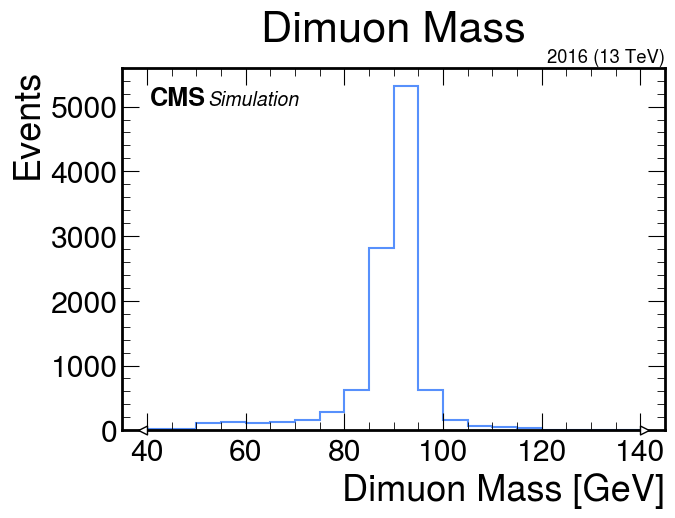

In [25]:
for dset, results in mumu_results.items():
    print(f"Dataset: {dset}")
    print(f"Event count: {results['EventCount']}")

#Make plot using mplhep for CMS-style plots
hep.style.use(hep.style.CMS)
fig,ax = plt.subplots(1,1,figsize=(7,4.7))
hep.histplot(mumu_results["ZToMuMu"]["Mass"])
hep.cms.label(year=2016,com=13,loc=1,fontsize=14)
ax.set_title("Dimuon Mass",y=1.07,pad=2)
ax.set_ylabel("Events")
plt.show()